In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

In [12]:
from pyomo.opt import SolverFactory
from pyomo.core import Var
import pyomo.environ as en
path_to_solver="/Applications/CPLEX_Studio2211/cplex/bin/arm64_osx/cplex"
import pickle

In [3]:
# load the data
with open('ID_heat_elec.pkl', 'rb') as f:
    ID_heat_elec = pickle.load(f)

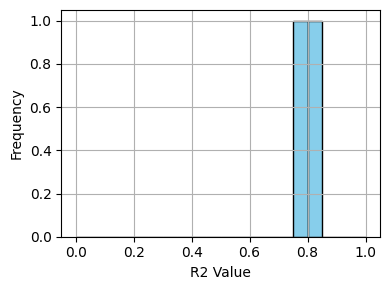

In [4]:
R2_values = [ID_heat_elec[key]['COP model']['R2'] for key in ID_heat_elec.keys()]

# Define bins within [0, 1] — for example, 20 equally spaced bins
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Plot
plt.figure(figsize=(4, 3))
plt.hist(R2_values, bins=bins, edgecolor='black', color='skyblue')
plt.xlabel('R2 Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
avg_prices_df  = pd.read_parquet("average_agile_tariff_UK.parquet")

In [10]:
price = avg_prices_df['avg_price'].values
print(f"The average electricity price is {np.mean(price):.4} £/kWh")

The average electricity price is 31.27 £/kWh


### PLAN

* We have a timeseries for the heat out for electric and hot water, as well as the electric for both heat and hot water
* We also have COP for both SH and DHW
* Set up an optimisation to minimise the total running cost $\sum_t E_t^{tot} \pi_t$, where $E_t^{tot} = E_t^{SH} + E_t^{DHW}$
* $Q^{SH}$ and $Q^{DHW}$ are the constraints, so must always be met
* Heat from the TES can reduce either, but it will reduce $E_t^{SH}$ by $\Delta Q_t^{TES}/COP_t^{SH}$
* it will reduce $E_t^{DHW}$ by $\Delta Q_t^{TES}/COP_t^{DHW}$
* Where $\Delta Q_t^{TES}$ is the output from the TES
* Constraints that $E_t^{SH}\geq0$ and $E_t^{DHW}\geq0$ 

<br>

* We can also run an optimisation to minimise the peak value of $E_t^{tot}$


In [17]:
keys = [key for key in ID_heat_elec.keys()]
EoH_ID = keys[0]

In [18]:
ID_heat_elec[EoH_ID]['HH_data'].columns

Index(['Heat_out', 'Heat_out_hot_water', 'Heat_out_space_heat',
       'Electric_hot_water', 'Electric_space_heat', 'deltaT_space_heat',
       'deltaT_hot_water', 'COP_space_heat', 'COP_hot_water'],
      dtype='object')

In [22]:
t = time.time()

print('EOH ID = '+EoH_ID)

Q_SH = ID_heat_elec[EoH_ID]['HH_data']['Heat_out_space_heat'].values
Q_DHW = ID_heat_elec[EoH_ID]['HH_data']['Heat_out_hot_water'].values

COP_SH = ID_heat_elec[EoH_ID]['HH_data']['COP_space_heat'].values
COP_DHW = ID_heat_elec[EoH_ID]['HH_data']['COP_hot_water'].values

# need to create an overlapping price array with the HH data
ts = ID_heat_elec[EoH_ID]['HH_data'].index.tz_localize('UTC')
concurrent_prices = avg_prices_df[(avg_prices_df.index>=ts[0]) & (avg_prices_df.index<=ts[-1])]
price = concurrent_prices['avg_price'].values

# Set negative or NaN heat values to zero
Q_SH = np.where((Q_SH < 0) | (~np.isfinite(Q_SH)), 0.0, Q_SH)
Q_DHW = np.where((Q_DHW < 0) | (~np.isfinite(Q_DHW)), 0.0, Q_DHW)

# --- Identify invalid COPs (NaN, inf, or ≤ 0) ---
invalid_COP_SH = (~np.isfinite(COP_SH)) | (COP_SH < 1)
invalid_COP_DHW = (~np.isfinite(COP_DHW)) | (COP_DHW < 1)

COP_SH = np.where(invalid_COP_SH, 1.0, COP_SH)
COP_DHW = np.where(invalid_COP_DHW, 1.0, COP_DHW)

# --- Compute electric safely ---
E_SH = Q_SH / COP_SH
E_DHW = Q_DHW / COP_DHW
E_tot = E_SH + E_DHW

thermal_store_caps = [10,30]
thermal_powers = [T/4 for T in thermal_store_caps]
charge_powers = [2.5 for T in thermal_store_caps]

######### Optimisation to minimise running costs
totalCost = np.zeros((len(thermal_store_caps)+1))
totalElecUsage = np.zeros((len(thermal_store_caps)+1))
maxHeatOut = np.zeros((len(thermal_store_caps)+1))

for opt_count in range(len(thermal_store_caps)):

    # define the parameters for the thermal store
    TES1 = dict()
    TES1['capacity'] = thermal_store_caps[opt_count] #kWh
    TES1['chargeLimit'] = charge_powers[opt_count] #kWh per hour
    TES1['dischargeLimit'] = thermal_powers[opt_count] #kWh per hour
    TES1['SOC'] = np.zeros((len(Q_SH)))
    TES1['deltaSOC'] = np.zeros((len(Q_SH)))
    TES1['etaChg'] = 1. #both charging and discharging have 100% efficiency
    TES1['etaDis'] = 1. #round trip efficiency 100%
    TES1['initialCharge'] = 0
    Qout_lim = TES1['dischargeLimit'] * TES1['etaDis']

    Q_DictSH = dict(enumerate(Q_SH))
    Q_DictDHW = dict(enumerate(Q_DHW))
    E_Dict = dict(enumerate(E_tot))
    COP_DictSH = dict(enumerate(COP_SH))
    COP_DictDHW = dict(enumerate(COP_DHW))
    price_Dict = dict(enumerate(price))

    # now set up the pyomo model
    m = en.ConcreteModel()
    # we use rangeset to make a sequence of integers
    # time is what we will use as the model index
    m.Time = en.RangeSet(0, len(Q_SH)-1)

    #####################################################################################

    # variables (all indexed by Time)
    m.SOC = en.Var(m.Time, bounds=(0,TES1['capacity']), initialize=0) #0
    m.posDeltaSOC = en.Var(m.Time, bounds=(0, TES1['chargeLimit']), initialize=0) #1
    # posDeltaSOC is energy added to TES1
    m.negDeltaSOC = en.Var(m.Time, bounds=(-TES1['dischargeLimit'], 0), initialize=0) #2
    # negDeltaSOC is energy removed from TES1
    m.posEIn = en.Var(m.Time, initialize=0) #3
    # posEIn is energy required for posDeltaSOC
    m.negQOut = en.Var(m.Time, bounds=(-Qout_lim, 0), initialize=0) #4
    # negQOut is result of negDeltaSOC

    # variables to store the heat out to SH and DHW (since they have different COP)
    m.negQOut_SH = en.Var(m.Time, bounds=(-Qout_lim, 0), initialize=0) #5
    # negEOut_SH is the output from TES to SH system
    m.negQOut_DHW = en.Var(m.Time, bounds=(-Qout_lim, 0), initialize=0) #6
    # negEOut_DHW is the output from TES to DHW system

    m.netElec = en.Var(m.Time, initialize=0) #7
    # netElec will be the decision variable

    # introduce variables for tracking HP output
    m.netSH = en.Var(m.Time, initialize=0) #8
    m.netDHW = en.Var(m.Time, initialize=0) #9
    
    # Boolean variables (again indexed by Time)
    m.Bool_char=en.Var(m.Time,within=en.Boolean) 
    m.Bool_dis=en.Var(m.Time,within=en.Boolean,initialize=0) 

    # # parameters (indexed by time)
    m.price = en.Param(m.Time, initialize=price_Dict, within=en.Reals)
    m.Q_SH = en.Param(m.Time, initialize=Q_DictSH, within=en.NonNegativeReals)
    m.Q_DHW = en.Param(m.Time, initialize=Q_DictDHW, within=en.NonNegativeReals)

    # need a parameter for the original electric usage of the heat pump
    m.elec_Orig = en.Param(m.Time, initialize=E_Dict, within=en.NonNegativeReals)

    # COPs for DHW & SH
    m.COP_SH = en.Param(m.Time, initialize=COP_DictSH, within=en.NonNegativeReals)
    m.COP_DHW = en.Param(m.Time, initialize=COP_DictDHW, within=en.NonNegativeReals)

    # single value parameters
    m.etaChg = en.Param(initialize = TES1['etaChg'], within=en.PositiveReals)
    m.etaDisChg = en.Param(initialize = TES1['etaDis'], within=en.PositiveReals)

    #####################################################################################
    ##### if we are minimising the peak
    # # cost of the peak demand
    # m.cost_peak = en.Param(initialize=1)
    # m.cost_sum = en.Param(initialize=1E-4)

    # # we need a variable to store the max value of m.netLoad
    # m.maxElec = en.Var(domain=en.Reals) #9
    # def Peak_Rule(m, i):
    #     return m.maxElec >= m.netElec[i]
    # m.bound_peak = en.Constraint(m.Time,rule=Peak_Rule)

    # # objective function
    # def Obj_fn(m):
    #     return m.cost_peak*m.maxElec + m.cost_sum*sum(m.netElec[i] for i in m.Time)
    # m.total_cost = en.Objective(rule=Obj_fn,sense=en.minimize)

    #####################################################################################
    
    # objective function
    def Obj_fn(m):
        return sum(m.netElec[i]*m.price[i] for i in m.Time)
    m.total_cost = en.Objective(rule=Obj_fn,sense=en.minimize)

    #####################################################################################

    def SOC_rule(m,i):
        if i==0:
            return (m.SOC[i] == TES1['initialCharge'] + m.posDeltaSOC[i]+m.negDeltaSOC[i])
        else:
            return (m.SOC[i] == m.SOC[i-1]+m.posDeltaSOC[i]+m.negDeltaSOC[i])   
    # then we specify that this constraint is indexed by time
    m.store_SOC = en.Constraint(m.Time,rule=SOC_rule)

    #####################################################################################

    # boolean constraints
    def charge_on_rule(m, i):
        return m.posDeltaSOC[i] <= TES1['chargeLimit'] * m.Bool_char[i]
    m.charge_on_cons = en.Constraint(m.Time, rule=charge_on_rule)
    
    def discharge_on_rule(m, i):
        return m.negDeltaSOC[i] >= -TES1['dischargeLimit'] * m.Bool_dis[i]
    m.discharge_on_cons = en.Constraint(m.Time, rule=discharge_on_rule)
    
    def Batt_char_dis(m, i):
        return m.Bool_char[i] + m.Bool_dis[i] <= 1
    m.Batt_char_dis = en.Constraint(m.Time, rule=Batt_char_dis)

    #####################################################################################

    #ensure charging efficiency is divided
    def pos_E_in_rule(m,i):
        return m.posEIn[i] == m.posDeltaSOC[i]/m.etaChg
    m.posEIn_cons = en.Constraint(m.Time, rule=pos_E_in_rule)
    
    # heat out from TES can either go to DHW or SH
    def neg_Q_out_rule(m,i):
        return m.negQOut[i] == m.negQOut_SH[i] + m.negQOut_DHW[i] 
    m.negQOut_cons = en.Constraint(m.Time, rule=neg_Q_out_rule)
    
    # ensure discharging eff multiplied
    def neg_Q_out_tot_rule(m,i):
        return m.negQOut[i] == m.negDeltaSOC[i]*m.etaDisChg
    m.negQOut_tot_cons = en.Constraint(m.Time, rule=neg_Q_out_tot_rule)

    #####################################################################################

    # calculate the net electric demand
    def E_elec_rule(m,i):
        return m.netElec[i] == m.elec_Orig[i]+m.posEIn[i]+m.negQOut_SH[i]/m.COP_SH[i]+m.negQOut_DHW[i]/m.COP_DHW[i] 
        # resistance charges, reduces electric differently depending on whether meeting SH or DHW
    m.E_net_cons = en.Constraint(m.Time,rule=E_elec_rule)
    
    def Q_SH_rule(m,i):
        return m.netSH[i] == m.Q_SH[i] + m.negQOut_SH[i]
    m.Q_SH_cons = en.Constraint(m.Time,rule=Q_SH_rule)
    # New HP output --> SH

    def Q_DHW_rule(m,i):
        return m.netDHW[i] == m.Q_DHW[i] + m.negQOut_DHW[i]
    m.Q_DHW_cons = en.Constraint(m.Time,rule=Q_DHW_rule)
    # New HP output --> DHW

    #####################################################################################

    # don't allow storage to discharge if no SH or DHW
    def Q_neg_SH_rule(m,i):
        return m.netSH[i] >= 0
    m.E_Q_SH_cons = en.Constraint(m.Time,rule=Q_neg_SH_rule)
    def Q_neg_DHW_rule(m,i):
        return m.netDHW[i] >= 0
    m.E_Q_DHW_cons = en.Constraint(m.Time,rule=Q_neg_DHW_rule)

    # add a constraint that is dont allow for electric to reduce below zero
    def E_neg_elec_rule(m,i):
        return m.netElec[i] >= 0
    m.E_net_neg_elec_cons = en.Constraint(m.Time,rule=E_neg_elec_rule)

    #####################################################################################

    # set the path to the solver
    opt = SolverFactory("cplex", executable=path_to_solver)

    #####################################################################################

    results = opt.solve(m)

    #####################################################################################

    j = 0
    for v in m.component_objects(Var, active=True):
        # print(j, v.getname())
        j+=1

    #####################################################################################

    # now let's read in the value for each of the variables 
    outputVars = {}

    for v in m.component_objects(en.Var, active=True):
        varobject = getattr(m, str(v))
        outputVars[str(v)] = np.array([varobject[i].value for i in m.Time])

elapsed = time.time() - t
print('Time elapsed:', elapsed)

EOH ID = EOH0546


/var/folders/8n/j_jqqzc12y18dwhf8xy8gjqr0000gr/T/ipykernel_32142/2679687298.py:25: UserWarning: 1381 COP_SH values set to 1
  warnings.warn(f"{invalid_COP_SH.sum()} COP_SH values set to 1")
/var/folders/8n/j_jqqzc12y18dwhf8xy8gjqr0000gr/T/ipykernel_32142/2679687298.py:28: UserWarning: 16345 COP_DHW values set to 1
  warnings.warn(f"{invalid_COP_DHW.sum()} COP_DHW values set to 1")


Time elapsed: 9.365230798721313
